In [252]:
from google.colab import files

uploaded = files.upload()

Saving Scraped_Data.csv to Scraped_Data.csv


In [253]:
!pip install shap xgboost lightgbm catboost

In [254]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import shap

import warnings
warnings.filterwarnings("ignore")

In [255]:
df = pd.read_csv("/content/Scraped_Data.csv")

In [256]:
df.head()

,exactPrice,sqftPrice,securityDeposit,propertyType,postedOn,noOfLifts,maintenanceChargesFrequency,maintenanceCharges,locality,furnishing,...,Cafeteria_Or_Food_Court,CCTV_Camera,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM
0,240000,171,9,Multistorey Apartment,"Jun 20, '23",9.0,9,9,Danapur,Semi-Furnished,...,1,0,0,1,1,0,0,0,0,0
1,12000,12,12000,Multistorey Apartment,"Jun 19, '23",1.0,Monthly,1500,9,Semi-Furnished,...,9,9,9,9,9,9,9,9,9,9
2,17000,7,9,Residential House,"Jun 21, '23",9.0,9,9,Phase 1 Ashiana Nagar,Semi-Furnished,...,9,9,9,9,9,9,9,9,9,9
3,5000,9,9,Residential House,"Jun 23, '23",9.0,9,9,Kumhrar,Furnished,...,9,9,9,9,9,9,9,9,9,9
4,12000,9,24000,Multistorey Apartment,"Jun 24, '23",1.0,Monthly,500,Kumhrar,Unfurnished,...,9,9,9,9,9,9,9,9,9,9


In [257]:
df.tail()

,exactPrice,sqftPrice,securityDeposit,propertyType,postedOn,noOfLifts,maintenanceChargesFrequency,maintenanceCharges,locality,furnishing,...,Cafeteria_Or_Food_Court,CCTV_Camera,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM
27895,20227500,7500,9,Multistorey Apartment,"Jul 01, '23",2.0,Monthly,9,Dalanwala,Semi-Furnished,...,0,0,0,0,0,0,0,0,0,0
27896,6933500,4900,9,Multistorey Apartment,"Jun 30, '23",9.0,9,9,Canal Road,Semi-Furnished,...,0,0,0,0,0,0,0,0,0,0
27897,9000000,8182,9,Villa,"Jul 02, '23",9.0,9,9,Aman Vihar,Unfurnished,...,9,9,9,9,9,9,9,9,9,9
27898,7645000,5500,9,Multistorey Apartment,"Jul 01, '23",9.0,9,9,Sahastradhara Road,Unfurnished,...,0,0,0,1,0,0,0,0,0,0
27899,11525400,5700,9,Multistorey Apartment,"Jun 30, '23",2.0,Monthly,9,General Mahadev Singh Road,Semi-Furnished,...,0,0,0,0,0,0,0,0,0,0


In [258]:
df.shape

(27900, 91)

In [259]:
df.columns

Index(['exactPrice', 'sqftPrice', 'securityDeposit', 'propertyType',
       'postedOn', 'noOfLifts', 'maintenanceChargesFrequency',
       'maintenanceCharges', 'locality', 'furnishing', 'flrNum',
       'firstMonthCharges', 'facing', 'totalFlrNum', 'city', 'carpetAreaUnit',
       'carpetArea', 'brokerage', 'bedrooms', 'bathrooms', 'balconies',
       'Water_Storage', 'Waste_Disposal', 'Visitor_Parking',
       'Vaastu_Compliant', 'URLs', 'Swimming_Pool', 'Skydeck',
       'Service_Or_Goods_Lift', 'Security',
       'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking',
       'Rentable_Community_Space', 'RentOrSale', 'Recreational_Pool',
       'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden',
       'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park',
       'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts',
       'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long',
       'Lift', 'Library_And_Business_Centre', 'Librar

In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27900 entries, 0 to 27899
Data columns (total 91 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   exactPrice                            27900 non-null  int64  
 1   sqftPrice                             27900 non-null  int64  
 2   securityDeposit                       27900 non-null  int64  
 3   propertyType                          27900 non-null  object 
 4   postedOn                              27900 non-null  object 
 5   noOfLifts                             27445 non-null  float64
 6   maintenanceChargesFrequency           27900 non-null  object 
 7   maintenanceCharges                    27900 non-null  int64  
 8   locality                              27900 non-null  object 
 9   furnishing                            27900 non-null  object 
 10  flrNum                                27900 non-null  object 
 11  firstMonthCharg

In [261]:
df.describe()

,exactPrice,sqftPrice,securityDeposit,noOfLifts,maintenanceCharges,firstMonthCharges,totalFlrNum,carpetArea,bedrooms,bathrooms,...,Cafeteria_Or_Food_Court,CCTV_Camera,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM
count,2.790000e+04,2.790000e+04,2.790000e+04,27445.000000,2.790000e+04,2.790000e+04,27900.000000,27900.000000,27900.000000,27900.000000,...,27900.000000,27900.000000,27900.00000,27900.000000,27900.000000,27900.000000,27900.000000,27900.000000,27900.000000,27900.000000
mean,5.427532e+06,4.293275e+04,2.407937e+04,7.870978,2.902351e+05,3.327781e+05,5.665520,609.963584,2.673047,2.483082,...,7.152724,7.155484,7.12319,7.133513,7.175627,7.134624,7.121900,7.141792,7.127204,7.147455
std,2.699586e+07,2.264502e+06,1.074923e+05,2.602134,4.835278e+07,4.835763e+07,7.012247,837.434426,1.418080,1.490751,...,3.594546,3.589433,3.64868,3.629878,3.551828,3.627847,3.651021,3.614706,3.641383,3.604280
min,9.000000e+00,0.000000e+00,1.000000e+00,1.000000,0.000000e+00,9.000000e+00,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.300000e+04,1.100000e+01,9.000000e+00,9.000000,9.000000e+00,9.000000e+00,2.000000,9.000000,2.000000,2.000000,...,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
50%,3.000000e+04,2.100000e+01,9.000000e+00,9.000000,9.000000e+00,9.000000e+00,4.000000,125.000000,2.000000,2.000000,...,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
75%,5.269500e+06,3.864250e+03,1.400000e+04,9.000000,9.000000e+00,3.000000e+04,7.000000,1050.000000,3.000000,3.000000,...,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
max,3.250000e+09,2.000000e+08,5.000000e+06,10.000000,8.076500e+09,8.076537e+09,200.000000,13000.000000,10.000000,10.000000,...,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


In [262]:
df.isnull().sum()

,0
exactPrice,0
sqftPrice,0
securityDeposit,0
propertyType,0
postedOn,0
...,...
Bank__And__ATM,0
Arts__And__Craft_Studio,0
Air_Conditioned,0
Activity_Deck4,0


In [263]:
df.duplicated().sum()

np.int64(11)

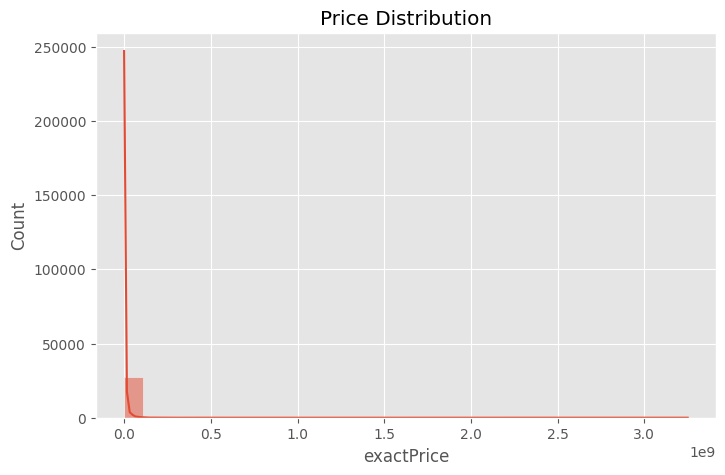

In [264]:
plt.figure(figsize=(8,5))
sns.histplot(df['exactPrice'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

In [265]:
# Create a copy of the original dataset
clean_df = df.copy()

In [266]:
clean_df.isnull().sum().sort_values(ascending=False)

,0
noOfLifts,455
city,1
sqftPrice,0
securityDeposit,0
propertyType,0
...,...
Bank__And__ATM,0
Arts__And__Craft_Studio,0
Air_Conditioned,0
Activity_Deck4,0


In [267]:
missing_percentage = (clean_df.isnull().sum() / len(clean_df)) * 100

missing_percentage.sort_values(ascending=False)

,0
noOfLifts,1.630824
city,0.003584
sqftPrice,0.000000
securityDeposit,0.000000
propertyType,0.000000
...,...
Bank__And__ATM,0.000000
Arts__And__Craft_Studio,0.000000
Air_Conditioned,0.000000
Activity_Deck4,0.000000


In [268]:
clean_df = clean_df.drop_duplicates()

print("Remaining rows:", clean_df.shape[0])

Remaining rows: 27889


In [269]:
clean_df.dtypes

,0
exactPrice,int64
sqftPrice,int64
securityDeposit,int64
propertyType,object
postedOn,object
...,...
Bank__And__ATM,int64
Arts__And__Craft_Studio,int64
Air_Conditioned,int64
Activity_Deck4,int64


In [270]:
numerical_columns = clean_df.select_dtypes(include=['int64','float64']).columns

categorical_columns = clean_df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print()

print("Categorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['exactPrice', 'sqftPrice', 'securityDeposit', 'noOfLifts',
       'maintenanceCharges', 'firstMonthCharges', 'totalFlrNum', 'carpetArea',
       'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal',
       'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck',
       'Service_Or_Goods_Lift', 'Security',
       'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking',
       'Rentable_Community_Space', 'Recreational_Pool',
       'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden',
       'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park',
       'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts',
       'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long',
       'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service',
       'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area',
       'Kids_Club', 'Jogging_and_Strolling_Track',
       'Internet_Or_Wi_Fi_

In [271]:
for col in numerical_columns:
    clean_df[col].fillna(clean_df[col].median(), inplace=True)

In [272]:
for col in categorical_columns:
    clean_df[col].fillna(clean_df[col].mode()[0], inplace=True)

In [273]:
clean_df.isnull().sum()

,0
exactPrice,0
sqftPrice,0
securityDeposit,0
propertyType,0
postedOn,0
...,...
Bank__And__ATM,0
Arts__And__Craft_Studio,0
Air_Conditioned,0
Activity_Deck4,0


In [274]:
clean_df.to_csv("cleaned_real_estate.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [275]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [276]:
clean_df.head()

,exactPrice,sqftPrice,securityDeposit,propertyType,postedOn,noOfLifts,maintenanceChargesFrequency,maintenanceCharges,locality,furnishing,...,Cafeteria_Or_Food_Court,CCTV_Camera,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM
0,240000,171,9,Multistorey Apartment,"Jun 20, '23",9.0,9,9,Danapur,Semi-Furnished,...,1,0,0,1,1,0,0,0,0,0
1,12000,12,12000,Multistorey Apartment,"Jun 19, '23",1.0,Monthly,1500,9,Semi-Furnished,...,9,9,9,9,9,9,9,9,9,9
2,17000,7,9,Residential House,"Jun 21, '23",9.0,9,9,Phase 1 Ashiana Nagar,Semi-Furnished,...,9,9,9,9,9,9,9,9,9,9
3,5000,9,9,Residential House,"Jun 23, '23",9.0,9,9,Kumhrar,Furnished,...,9,9,9,9,9,9,9,9,9,9
4,12000,9,24000,Multistorey Apartment,"Jun 24, '23",1.0,Monthly,500,Kumhrar,Unfurnished,...,9,9,9,9,9,9,9,9,9,9


In [277]:
print("Numerical Columns")
print(clean_df.select_dtypes(include=['int64','float64']).columns)

print()

print("Categorical Columns")
print(clean_df.select_dtypes(include=['object']).columns)

Numerical Columns
Index(['exactPrice', 'sqftPrice', 'securityDeposit', 'noOfLifts',
       'maintenanceCharges', 'firstMonthCharges', 'totalFlrNum', 'carpetArea',
       'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal',
       'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck',
       'Service_Or_Goods_Lift', 'Security',
       'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking',
       'Rentable_Community_Space', 'Recreational_Pool',
       'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden',
       'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park',
       'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts',
       'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long',
       'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service',
       'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area',
       'Kids_Club', 'Jogging_and_Strolling_Track',
       'Internet_Or_Wi_Fi_C

In [278]:
clean_df.columns

Index(['exactPrice', 'sqftPrice', 'securityDeposit', 'propertyType',
       'postedOn', 'noOfLifts', 'maintenanceChargesFrequency',
       'maintenanceCharges', 'locality', 'furnishing', 'flrNum',
       'firstMonthCharges', 'facing', 'totalFlrNum', 'city', 'carpetAreaUnit',
       'carpetArea', 'brokerage', 'bedrooms', 'bathrooms', 'balconies',
       'Water_Storage', 'Waste_Disposal', 'Visitor_Parking',
       'Vaastu_Compliant', 'URLs', 'Swimming_Pool', 'Skydeck',
       'Service_Or_Goods_Lift', 'Security',
       'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking',
       'Rentable_Community_Space', 'RentOrSale', 'Recreational_Pool',
       'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden',
       'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park',
       'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts',
       'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long',
       'Lift', 'Library_And_Business_Centre', 'Librar

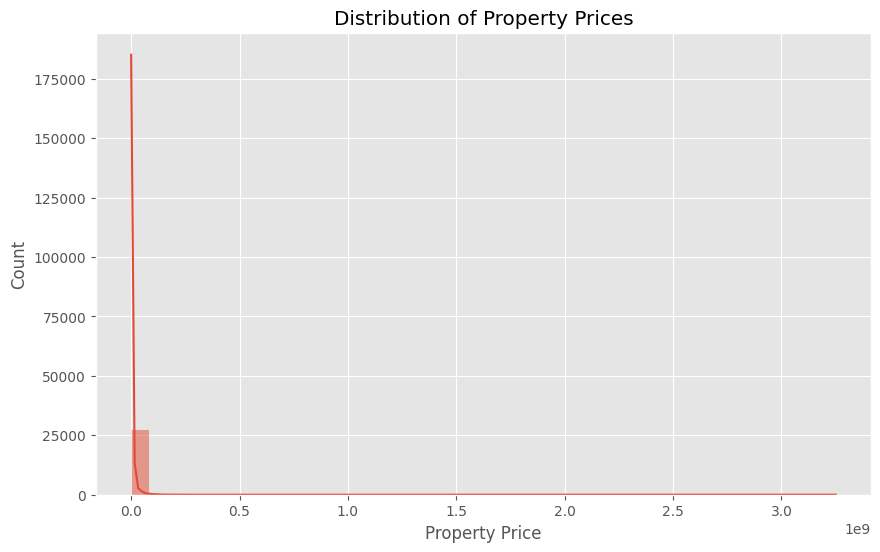

In [279]:
plt.figure(figsize=(10,6))

sns.histplot(clean_df["exactPrice"], bins=40, kde=True)

plt.title("Distribution of Property Prices")
plt.xlabel("Property Price")
plt.ylabel("Count")

plt.show()

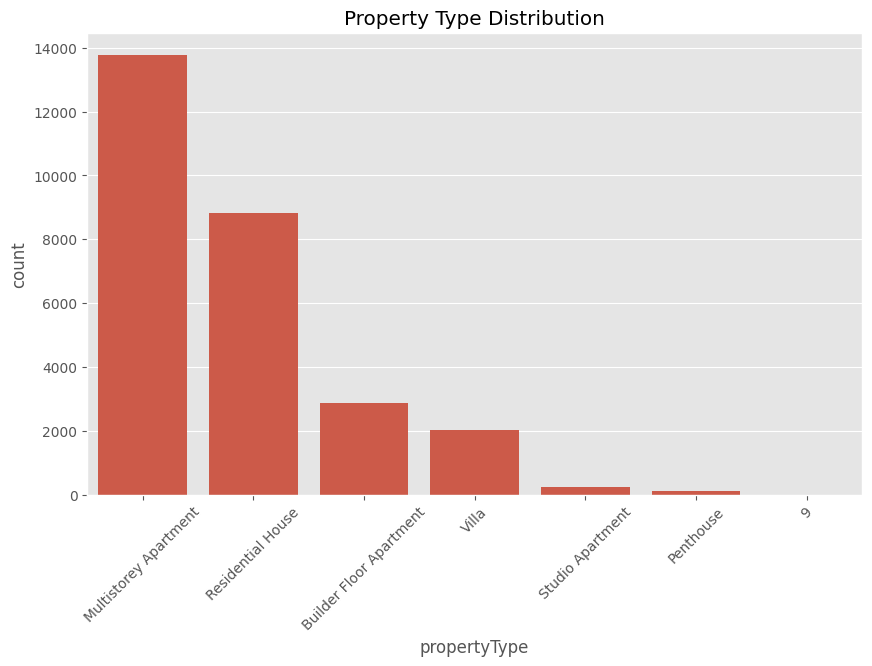

In [280]:
plt.figure(figsize=(10,6))

sns.countplot(data=clean_df,
              x="propertyType",
              order=clean_df["propertyType"].value_counts().index)

plt.xticks(rotation=45)

plt.title("Property Type Distribution")

plt.show()

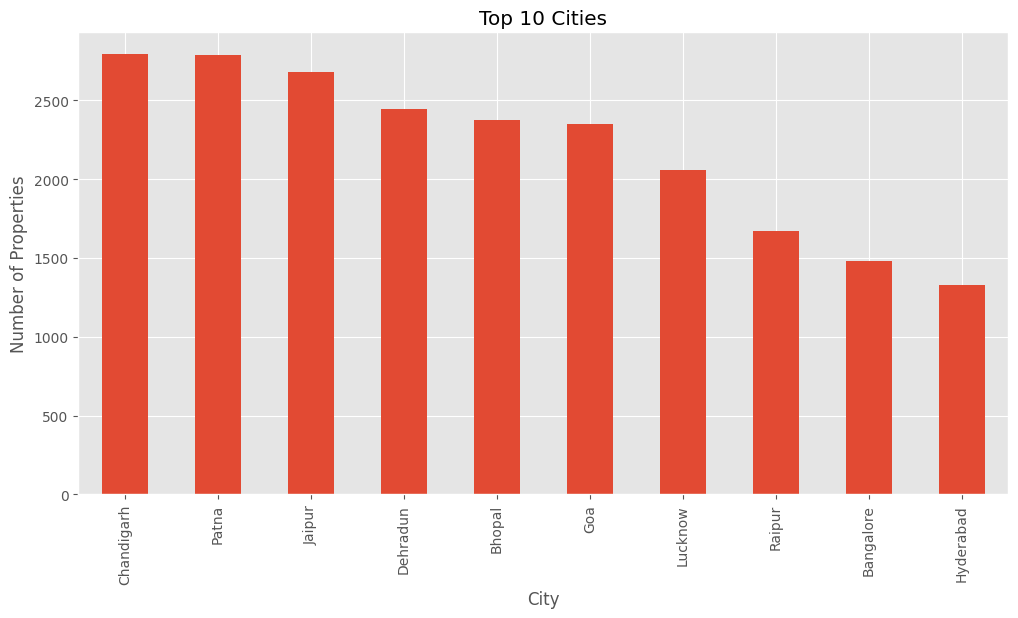

In [281]:
plt.figure(figsize=(12,6))

clean_df["city"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Cities")

plt.xlabel("City")

plt.ylabel("Number of Properties")

plt.show()

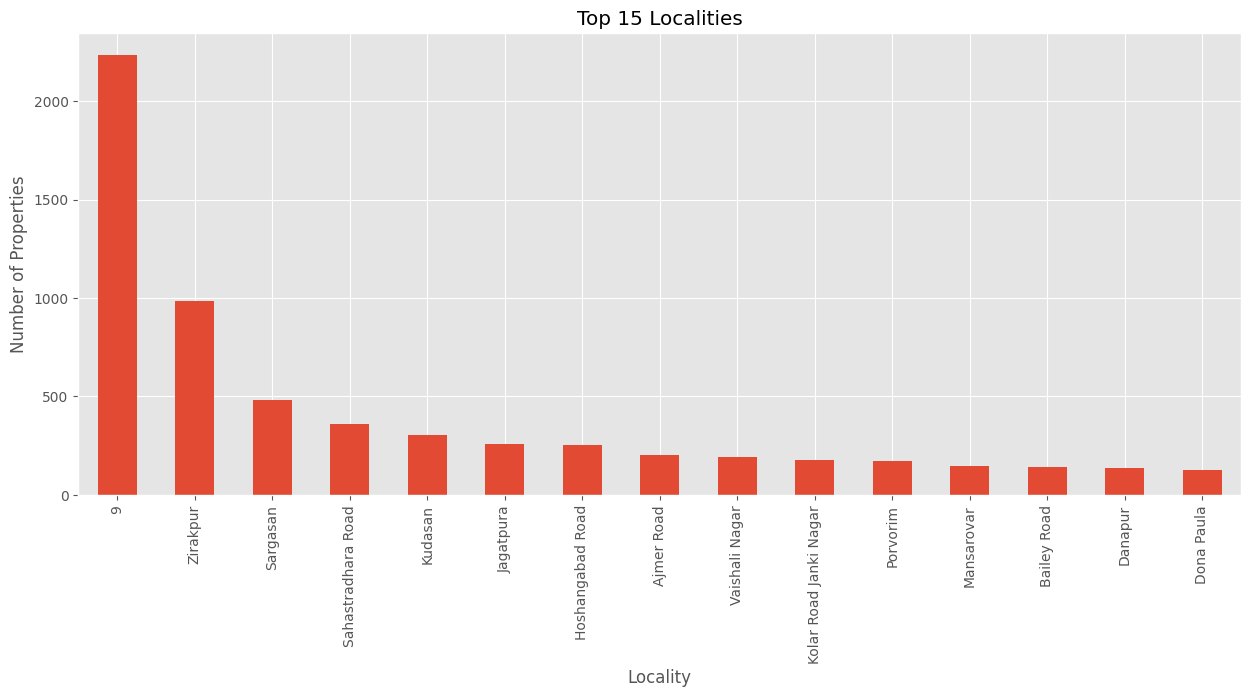

In [282]:
plt.figure(figsize=(15,6))

clean_df["locality"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Localities")

plt.xlabel("Locality")

plt.ylabel("Number of Properties")

plt.show()

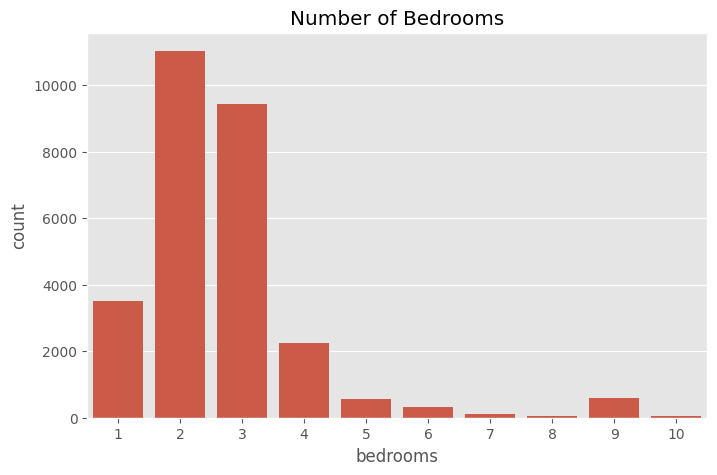

In [283]:
plt.figure(figsize=(8,5))

sns.countplot(data=clean_df, x="bedrooms")

plt.title("Number of Bedrooms")

plt.show()

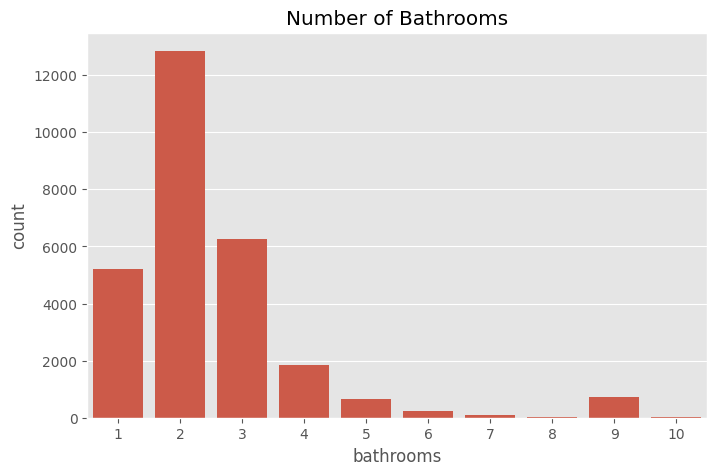

In [284]:
plt.figure(figsize=(8,5))

sns.countplot(data=clean_df, x="bathrooms")

plt.title("Number of Bathrooms")

plt.show()

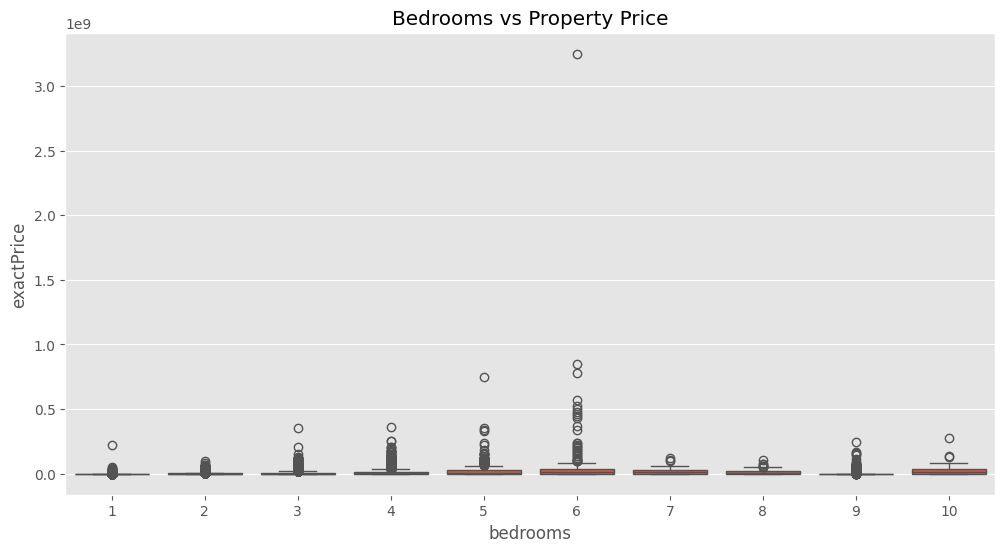

In [285]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=clean_df,
    x="bedrooms",
    y="exactPrice"
)

plt.title("Bedrooms vs Property Price")

plt.show()

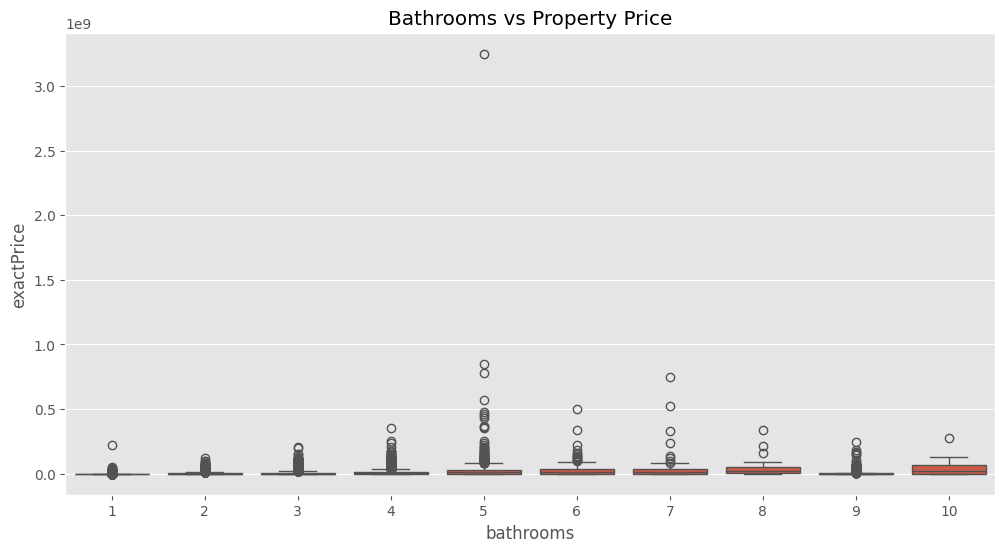

In [286]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=clean_df,
    x="bathrooms",
    y="exactPrice"
)

plt.title("Bathrooms vs Property Price")

plt.show()

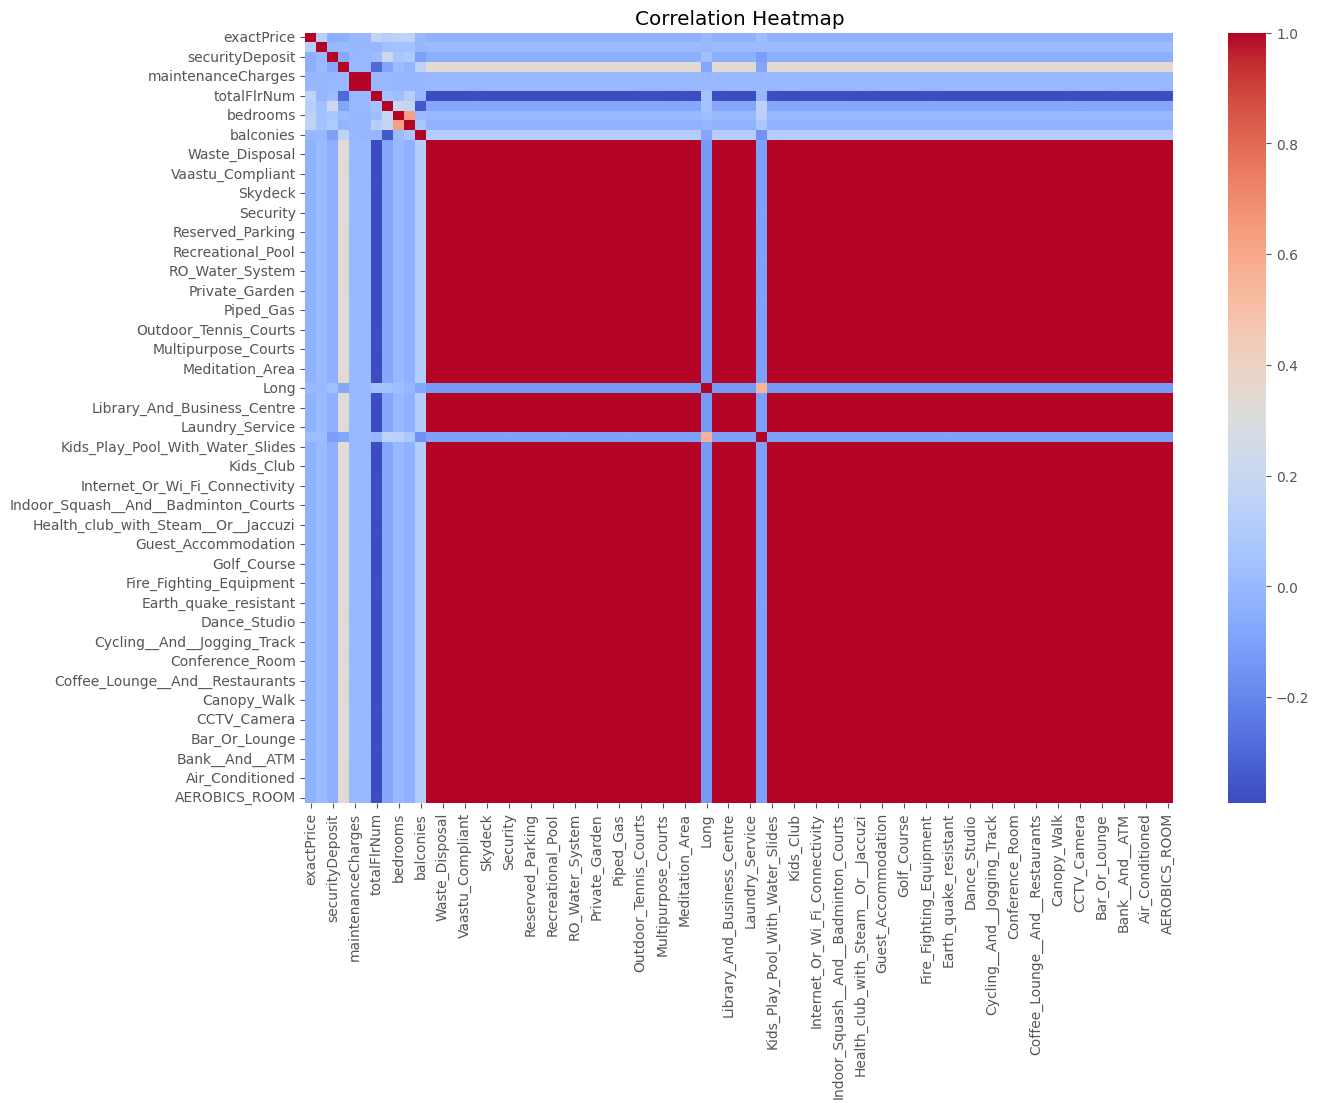

In [287]:
plt.figure(figsize=(14,10))

sns.heatmap(
    clean_df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

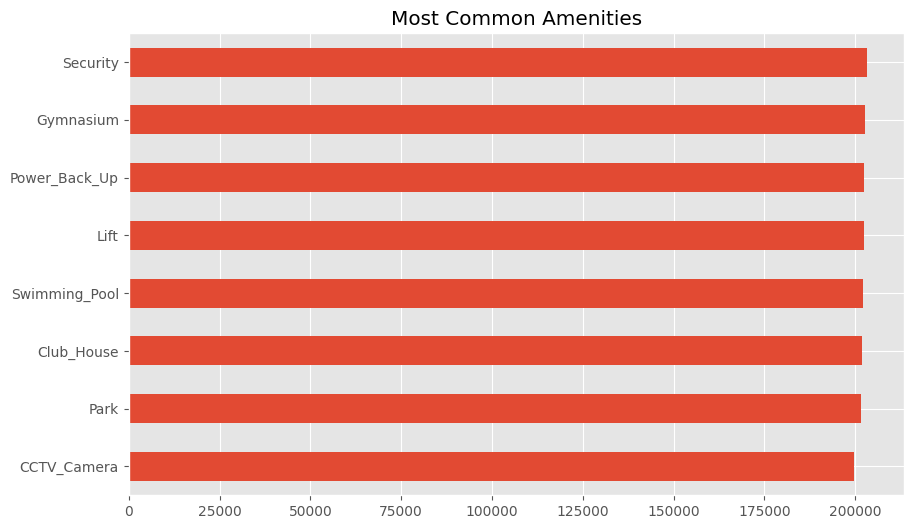

In [288]:
amenities = [
    "Gymnasium",
    "Swimming_Pool",
    "Power_Back_Up",
    "Lift",
    "Security",
    "CCTV_Camera",
    "Club_House",
    "Park"
]

clean_df[amenities].sum().sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Most Common Amenities")

plt.show()

In [289]:
# Create a copy for feature engineering
feature_df = clean_df.copy()

print(feature_df.shape)

(27889, 91)


In [344]:
# Drop unnecessary columns
feature_df.drop(
    columns=["URLs", "Lat", "Long"],
    inplace=True,
    errors="ignore"
)

In [345]:
feature_df["postedOn"] = pd.to_datetime(
    feature_df["postedOn"],
    errors="coerce"
)

feature_df["Posted_Year"] = feature_df["postedOn"].dt.year

feature_df["Posted_Month"] = feature_df["postedOn"].dt.month

feature_df.drop(columns=["postedOn"], inplace=True)

In [346]:
feature_df["Posted_Year"] = feature_df["Posted_Year"].fillna(
    feature_df["Posted_Year"].median()
)

feature_df["Posted_Month"] = feature_df["Posted_Month"].fillna(
    feature_df["Posted_Month"].median()
)

In [347]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = feature_df.select_dtypes(include="object").columns

encoders = {}

for col in categorical_columns:

    encoder = LabelEncoder()

    feature_df[col] = encoder.fit_transform(
        feature_df[col].astype(str)
    )

    encoders[col] = encoder

In [348]:
import joblib

joblib.dump(
    encoders,
    "label_encoders.pkl"
)

print("Label Encoders Saved Successfully!")

Label Encoders Saved Successfully!


In [298]:
feature_df.head()

,exactPrice,sqftPrice,securityDeposit,propertyType,noOfLifts,maintenanceChargesFrequency,maintenanceCharges,locality,furnishing,flrNum,...,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM,Posted_Year,Posted_Month
0,240000,171,9,2,9.0,0,9,797,2,33,...,0,1,1,0,0,0,0,0,2023.0,6.0
1,12000,12,12000,2,1.0,1,1500,9,2,33,...,9,9,9,9,9,9,9,9,2023.0,6.0
2,17000,7,9,4,9.0,0,9,2564,2,59,...,9,9,9,9,9,9,9,9,2023.0,6.0
3,5000,9,9,4,9.0,0,9,1804,1,58,...,9,9,9,9,9,9,9,9,2023.0,6.0
4,12000,9,24000,2,1.0,1,500,1804,3,0,...,9,9,9,9,9,9,9,9,2023.0,6.0


In [299]:
X = feature_df.drop(
    "exactPrice",
    axis=1
)

y = feature_df["exactPrice"]

print(X.shape)
print(y.shape)

(27889, 88)
(27889,)


In [300]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(22311, 88)
(5578, 88)


In [301]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    print("=" * 60)
    print(model.__class__.__name__)
    print("=" * 60)
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2 Score:", round(r2, 4))

    return model, predictions

In [302]:
feature_df.to_csv(
    "feature_engineered_dataset.csv",
    index=False
)

print("Feature engineering completed successfully!")

Feature engineering completed successfully!


In [303]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (22311, 88)
Testing Features  : (5578, 88)
Training Target   : (22311,)
Testing Target    : (5578,)


In [304]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [305]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Evaluation metrics
    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    print("=" * 60)
    print(model.__class__.__name__)
    print("=" * 60)

    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R2 Score:", round(r2,4))

    return model, predictions

In [306]:
linear_model = LinearRegression()

linear_model, linear_predictions = evaluate_model(
    linear_model,
    X_train,
    X_test,
    y_train,
    y_test
)

LinearRegression
MAE : 6113166.66
RMSE: 16335414.0
R2 Score: 0.2178


In [307]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model, tree_predictions = evaluate_model(
    tree_model,
    X_train,
    X_test,
    y_train,
    y_test
)

DecisionTreeRegressor
MAE : 2050003.71
RMSE: 11058422.4
R2 Score: 0.6416


In [308]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model, forest_predictions = evaluate_model(
    forest_model,
    X_train,
    X_test,
    y_train,
    y_test
)

RandomForestRegressor
MAE : 1506725.72
RMSE: 9659241.18
R2 Score: 0.7265


In [309]:
xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=100
)

xgb_model, xgb_predictions = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

XGBRegressor
MAE : 1994134.5
RMSE: 21584348.38
R2 Score: -0.3656


In [310]:
cat_model = CatBoostRegressor(
    verbose=0,
    random_state=42
)

cat_model, cat_predictions = evaluate_model(
    cat_model,
    X_train,
    X_test,
    y_train,
    y_test
)

CatBoostRegressor
MAE : 1762655.07
RMSE: 8396485.8
R2 Score: 0.7934


In [311]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model, gb_predictions = evaluate_model(
    gb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

GradientBoostingRegressor
MAE : 2153509.81
RMSE: 11759349.72
R2 Score: 0.5947


In [312]:
!pip install lightgbm

In [313]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    random_state=42
)

lgb_model, lgb_predictions = evaluate_model(
    lgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1740
[LightGBM] [Info] Number of data points in the train set: 22311, number of used features: 88
[LightGBM] [Info] Start training from score 5484858.641657
LGBMRegressor
MAE : 1790377.46
RMSE: 9519702.38
R2 Score: 0.7344


In [314]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "CatBoost",
        "LightGBM"
    ],

    "MAE":[
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, tree_predictions),
        mean_absolute_error(y_test, forest_predictions),
        mean_absolute_error(y_test, gb_predictions),
        mean_absolute_error(y_test, xgb_predictions),
        mean_absolute_error(y_test, cat_predictions),
        mean_absolute_error(y_test, lgb_predictions)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, tree_predictions)),
        np.sqrt(mean_squared_error(y_test, forest_predictions)),
        np.sqrt(mean_squared_error(y_test, gb_predictions)),
        np.sqrt(mean_squared_error(y_test, xgb_predictions)),
        np.sqrt(mean_squared_error(y_test, cat_predictions)),
        np.sqrt(mean_squared_error(y_test, lgb_predictions))
    ],

    "R2 Score":[
        r2_score(y_test, linear_predictions),
        r2_score(y_test, tree_predictions),
        r2_score(y_test, forest_predictions),
        r2_score(y_test, gb_predictions),
        r2_score(y_test, xgb_predictions),
        r2_score(y_test, cat_predictions),
        r2_score(y_test, lgb_predictions)
    ]
})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

comparison

,Model,MAE,RMSE,R2 Score
5,CatBoost,1.762655e+06,8.396486e+06,0.793353
6,LightGBM,1.790377e+06,9.519702e+06,0.734368
2,Random Forest,1.506726e+06,9.659241e+06,0.726524
1,Decision Tree,2.050004e+06,1.105842e+07,0.641557
3,Gradient Boosting,2.153510e+06,1.175935e+07,0.594678
0,Linear Regression,6.113167e+06,1.633541e+07,0.217843
4,XGBoost,1.994134e+06,2.158435e+07,-0.365562


In [315]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : CatBoost


In [316]:
import joblib

models = {

    "Linear Regression": linear_model,

    "Decision Tree": tree_model,

    "Random Forest": forest_model,

    "Gradient Boosting": gb_model,

    "XGBoost": xgb_model,

    "CatBoost": cat_model,

    "LightGBM": lgb_model

}

best_model = models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [317]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = clean_df.select_dtypes(include="object").columns

feature_df = clean_df.copy()

for col in categorical_columns:
    le = LabelEncoder()
    feature_df[col] = le.fit_transform(feature_df[col].astype(str))
    encoders[col] = le

In [318]:
joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [319]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
0,sqftPrice,34.288798
14,carpetArea,16.194345
10,facing,11.760706
17,bathrooms,8.615762
16,bedrooms,7.476093
6,locality,4.076402
8,flrNum,3.823019
18,balconies,3.122991
13,carpetAreaUnit,2.683220
30,RentOrSale,2.106569


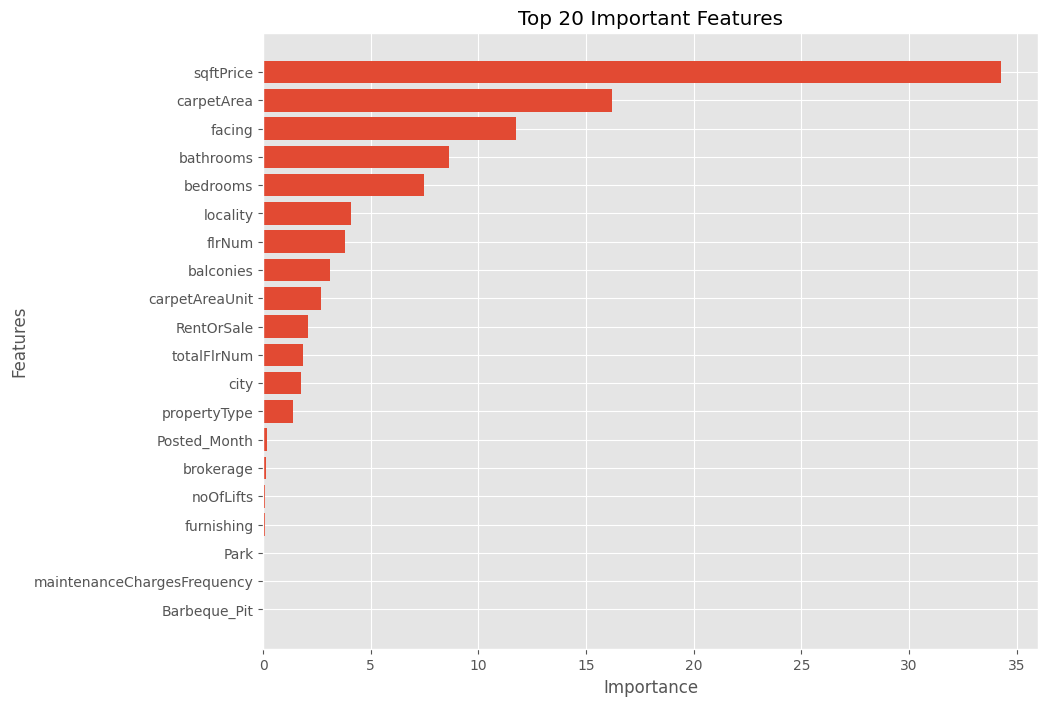

In [320]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [321]:
!pip install shap

In [322]:
import shap

In [323]:
explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(X_test)

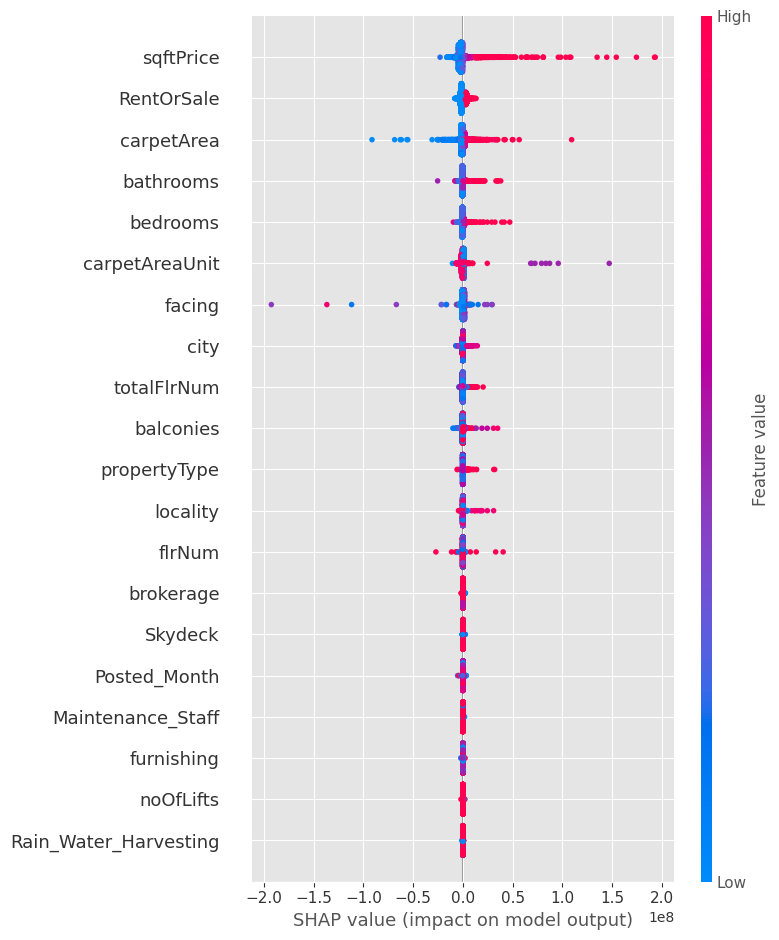

In [324]:
shap.summary_plot(
    shap_values,
    X_test
)

In [325]:
sample = X_test.iloc[[0]]

prediction = cat_model.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 4660657.63798299


In [326]:
print("Actual Price:", y_test.iloc[0])

Actual Price: 4500000


In [327]:
predictions = cat_model.predict(X_test)

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

results.head()

,Actual Price,Predicted Price
21344,4500000,4.660658e+06
6479,15000,-8.324037e+04
6258,15000,-4.014619e+05
5570,18000,4.178769e+05
16565,4900000,5.347983e+06


In [328]:
results.to_csv(
    "Predictions.csv",
    index=False
)

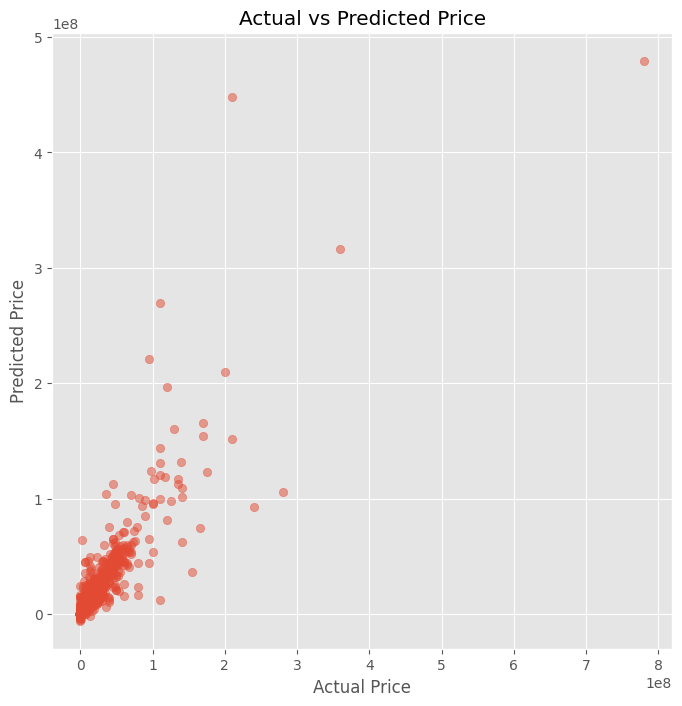

In [329]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

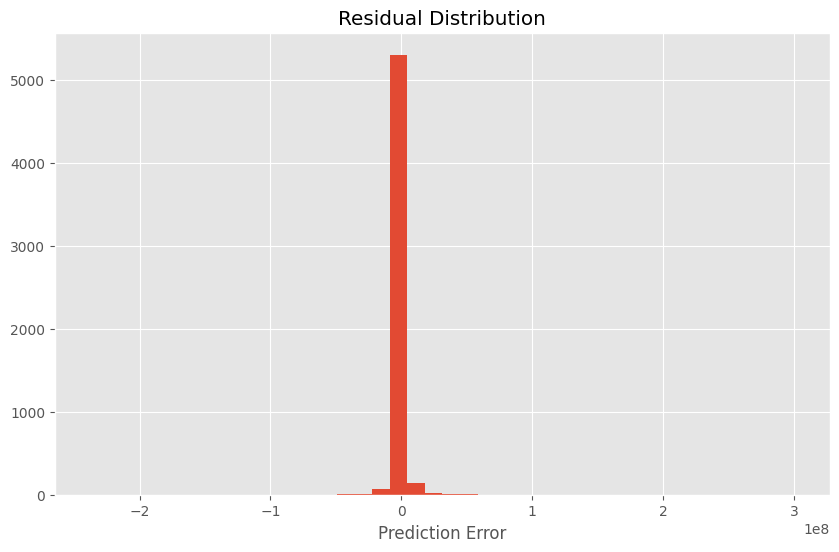

In [330]:
residuals = y_test - predictions

plt.figure(figsize=(10,6))

plt.hist(
    residuals,
    bins=40
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [331]:
available_features = [col for col in top_features if col in feature_df.columns]

X_new = feature_df[available_features]

y = feature_df["exactPrice"]

In [332]:
# Convert required columns to numeric
df["flrNum"] = pd.to_numeric(df["flrNum"], errors="coerce").fillna(0)
df["maintenanceCharges"] = pd.to_numeric(df["maintenanceCharges"], errors="coerce").fillna(0)

# Initialize Risk Score
df["RiskScore"] = 0

df.loc[df["flrNum"] > 15, "RiskScore"] += 10
df.loc[df["maintenanceCharges"] > 5000, "RiskScore"] += 15
df.loc[df["Lift"] == 0, "RiskScore"] += 10
df.loc[df["CCTV_Camera"] == 0, "RiskScore"] += 15
df.loc[df["Security"] == 0, "RiskScore"] += 20
df.loc[df["Power_Back_Up"] == 0, "RiskScore"] += 10

In [333]:
# Create Risk Score

risk_score = []

for i in range(len(df)):

    score = 0

    # High floor is slightly risky
    if df.loc[i, "flrNum"] > 15:
        score += 10

    # Very high maintenance
    if df.loc[i, "maintenanceCharges"] > 5000:
        score += 15

    # No Lift
    if df.loc[i, "Lift"] == 0:
        score += 10

    # No CCTV
    if df.loc[i, "CCTV_Camera"] == 0:
        score += 15

    # No Security
    if df.loc[i, "Security"] == 0:
        score += 20

    # No Power Backup
    if df.loc[i, "Power_Back_Up"] == 0:
        score += 10

    risk_score.append(score)

df["RiskScore"] = risk_score

In [334]:
def risk_category(score):

    if score <= 20:
        return "Low"

    elif score <= 45:
        return "Medium"

    else:
        return "High"

df["RiskCategory"] = df["RiskScore"].apply(risk_category)

df[["RiskScore","RiskCategory"]].head()

,RiskScore,RiskCategory
0,25,Medium
1,0,Low
2,0,Low
3,0,Low
4,0,Low


In [335]:
average_sqft = df["sqftPrice"].mean()

df["ROI"] = ((average_sqft - df["sqftPrice"]) / average_sqft) * 100

df["ROI"] = df["ROI"].round(2)

df[["sqftPrice","ROI"]].head()

,sqftPrice,ROI
0,171,99.60
1,12,99.97
2,7,99.98
3,9,99.98
4,9,99.98


In [336]:
def recommendation(row):

    if row["ROI"] > 10 and row["RiskCategory"] == "Low":
        return "BUY"

    elif row["ROI"] > 0 and row["RiskCategory"] == "Medium":
        return "HOLD"

    else:
        return "SELL"

df["Recommendation"] = df.apply(recommendation, axis=1)

df[["ROI","RiskCategory","Recommendation"]].head()

,ROI,RiskCategory,Recommendation
0,99.60,Medium,HOLD
1,99.97,Low,BUY
2,99.98,Low,BUY
3,99.98,Low,BUY
4,99.98,Low,BUY


In [337]:
annual_growth = 0.08

df["Price_1_Year"] = df["exactPrice"] * (1 + annual_growth)

df["Price_3_Years"] = df["exactPrice"] * ((1 + annual_growth) ** 3)

df["Price_5_Years"] = df["exactPrice"] * ((1 + annual_growth) ** 5)

df[[
    "exactPrice",
    "Price_1_Year",
    "Price_3_Years",
    "Price_5_Years"
]].head()

,exactPrice,Price_1_Year,Price_3_Years,Price_5_Years
0,240000,259200.0,302330.880,352638.738432
1,12000,12960.0,15116.544,17631.936922
2,17000,18360.0,21415.104,24978.577306
3,5000,5400.0,6298.560,7346.640384
4,12000,12960.0,15116.544,17631.936922


In [338]:
top_locations = (
    df.groupby("locality")
      .agg({
          "ROI":"mean",
          "RiskScore":"mean",
          "exactPrice":"mean"
      })
      .sort_values("ROI", ascending=False)
      .head(10)
)

top_locations

,ROI,RiskScore,exactPrice
locality,,,
Bogmalo,100.00,0.0,9.0
Bogmalo Beach,100.00,0.0,9.0
Usha Bazar,99.99,0.0,7000.0
Nangli Sakrawati,99.99,0.0,5000.0
Paschim Barisha,99.99,0.0,7500.0
kalyan Nagar Murlipura,99.99,0.0,11000.0
Mansa,99.99,0.0,10000.0
Semra,99.99,0.0,10000.0
Bhauri,99.99,0.0,7000.0


In [339]:
comparison = df[[
    "locality",
    "exactPrice",
    "ROI",
    "RiskCategory",
    "Recommendation"
]].head(10)

comparison

,locality,exactPrice,ROI,RiskCategory,Recommendation
0,Danapur,240000,99.60,Medium,HOLD
1,9,12000,99.97,Low,BUY
2,Phase 1 Ashiana Nagar,17000,99.98,Low,BUY
3,Kumhrar,5000,99.98,Low,BUY
4,Kumhrar,12000,99.98,Low,BUY
5,Lalji Tola,18000,99.96,Low,BUY
6,Mitra Mandal Colony,8500,99.98,Low,BUY
7,9,10000,99.98,Low,BUY
8,Kaliket Nagar,11000,99.98,Low,BUY
9,Patna City,7000,99.97,Low,BUY


In [340]:
df.to_csv("RealEstate_Final.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [341]:
print(X.columns.tolist())

['sqftPrice', 'securityDeposit', 'propertyType', 'noOfLifts', 'maintenanceChargesFrequency', 'maintenanceCharges', 'locality', 'furnishing', 'flrNum', 'firstMonthCharges', 'facing', 'totalFlrNum', 'city', 'carpetAreaUnit', 'carpetArea', 'brokerage', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'RentOrSale', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Jogging_and_Strolling_Track', 'Internet_Or_Wi_Fi_Connec

In [342]:
print(feature_df.head(1).T)

                                0
exactPrice               240000.0
sqftPrice                   171.0
securityDeposit               9.0
propertyType                  2.0
postedOn                     83.0
...                           ...
Bank__And__ATM                0.0
Arts__And__Craft_Studio       0.0
Air_Conditioned               0.0
Activity_Deck4                0.0
AEROBICS_ROOM                 0.0

[91 rows x 1 columns]


In [343]:
print(feature_df.columns.tolist())

['exactPrice', 'sqftPrice', 'securityDeposit', 'propertyType', 'postedOn', 'noOfLifts', 'maintenanceChargesFrequency', 'maintenanceCharges', 'locality', 'furnishing', 'flrNum', 'firstMonthCharges', 'facing', 'totalFlrNum', 'city', 'carpetAreaUnit', 'carpetArea', 'brokerage', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'URLs', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'RentOrSale', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Joggin